# Aevo BTC Option Ticker Surface Analysis

The Polaris [Option Tickers](https://docs.polaris.supply/schemas/option-tickers) schema identifies
an option chain by normalized underlying `market` and each contract by venue-native `instrument`.
This notebook reconstructs a latest-state BTC chain from partial ticker updates, parses contract
identity, and studies moneyness, implied volatility, Greeks, and open interest.


## Setup

Aevo publishes frequent whole-chain updates. A two-second public window is normally enough to see
hundreds of contracts; progressively wider windows are tried when necessary. The iterator is capped
at 100,000 rows.


In [1]:
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from polaris_data import PolarisClient

for _candidate in (Path.cwd() / "notebooks", Path.cwd()):
    if (_candidate / "_polaris.py").exists():
        sys.path.insert(0, str(_candidate))
        break

from _polaris import accessible_bounds, bounded_rows

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 100)
warnings.filterwarnings("ignore", message=r".*snapshot coverage.*", category=UserWarning)


In [2]:
source = "aevo"
market = "BTC"
max_rows = 100_000


## Discover no-key option coverage

The catalog's preview cutoff is used as the accessible UTC day. This avoids accidentally requesting
authenticated history before or after the public sample.


In [3]:
with PolarisClient() as client:
    catalog = client.catalog(source=source, market=market)

market_info = catalog["markets"][0]
available_start, available_end = accessible_bounds(market_info)
print(f"No-key coverage: {available_start} -> {available_end}")
pd.Series(market_info)


No-key coverage: 2026-09-01 00:00:00+00:00 -> 2026-09-02 00:00:00+00:00


access                                           {'public_cutoff_date': '2026-09-01', 'status': 'preview'}
categories                                                                                       [options]
end                                                                               2026-09-02T23:57:28.363Z
instrument     {'base': 'BTC', 'lot_size': None, 'min_notional': None, 'quote': 'USDC', 'tick_size': None}
market                                                                                                 BTC
source                                                                                                aevo
source_type                                                                                           None
start                                                                             2026-08-24T00:14:00.405Z
symbol                                                                                                 BTC
dtype: object

## Query the whole chain

`option_tickers(...)` yields typed dictionaries. Missing fields mean the venue did not publish that
value in the update; they are not interpreted as zero.


In [4]:
option_rows = []
truncated = False

with PolarisClient() as client:
    for seconds in [2, 5, 15, 60]:
        window_start = available_start
        window_end = min(available_start + pd.Timedelta(seconds=seconds), available_end)
        option_rows, truncated = bounded_rows(
            client.option_tickers(
                source=source, market=market, from_=window_start, to=window_end, allow_gaps=True,
            ),
            max_rows,
        )
        if option_rows:
            break

if not option_rows:
    raise ValueError("No option ticker rows were found in the accessible public window")

print(f"Selected window: {window_start} -> {window_end}")
print(f"Ticker updates: {len(option_rows):,}; hit cap: {truncated}")
print(f"Distinct contracts: {len({row['instrument'] for row in option_rows}):,}")
option_rows[0]


Selected window: 2026-09-01 00:00:00+00:00 -> 2026-09-01 00:00:02+00:00
Ticker updates: 1,933; hit cap: False
Distinct contracts: 968


{'collector_sequence': 3375313,
 'collector_timestamp': 1788220800738,
 'data': {'forward_price': '80691.58',
  'greeks': {'delta': '0.028333',
   'gamma': '0.000002',
   'rho': '11.159602',
   'theta': '-5.152226',
   'vega': '39.365890'},
  'index_price': '78561.883218',
  'mark_iv': '0.540100',
  'mark_price': '312.140306',
  'open_interest': '0',
  'premium_currency': 'USDC'},
 'exchange_sequence': None,
 'exchange_timestamp': 1788220800225,
 'instrument': 'BTC-26MAR27-190000-C',
 'market': 'BTC',
 'source': 'aevo',
 'type': 'option_ticker'}

## Preserve precision, then reconstruct latest contract state

Ticker numeric values are decimal strings by design. They are converted only in the analysis frame.
The latest update for each exact instrument forms a cross-sectional chain snapshot.


In [5]:
precision_example = {
    key: type(option_rows[0]["data"].get(key)).__name__
    for key in ["mark_price", "mark_iv", "open_interest"]
}
precision_example


{'mark_price': 'str', 'mark_iv': 'str', 'open_interest': 'str'}

In [6]:
tickers_df = pd.json_normalize(option_rows)
tickers_df["timestamp"] = tickers_df.apply(
    lambda row: pd.to_datetime(
        row.get("collector_timestamp", row.get("timestamp")), unit="ms", utc=True
    ),
    axis=1,
)

rename_map = {column: column.removeprefix("data.") for column in tickers_df if column.startswith("data.")}
tickers_df = tickers_df.rename(columns=rename_map)
numeric_columns = [
    "mark_price", "bid_price", "ask_price", "index_price", "forward_price",
    "mark_iv", "bid_iv", "ask_iv", "open_interest",
    "greeks.delta", "greeks.gamma", "greeks.vega", "greeks.theta", "greeks.rho",
]
for column in numeric_columns:
    if column in tickers_df:
        tickers_df[column] = pd.to_numeric(tickers_df[column], errors="coerce")

chain_df = (
    tickers_df.sort_values("timestamp")
    .drop_duplicates("instrument", keep="last")
    .copy()
)

contract_pattern = re.compile(
    r"^(?P<base>[^-]+)-(?P<expiry>\d{2}[A-Z]{3}\d{2})-(?P<strike>\d+(?:\.\d+)?)-(?P<option_type>[CP])$"
)
parsed = chain_df["instrument"].str.extract(contract_pattern)
chain_df = pd.concat([chain_df, parsed], axis=1)
chain_df["expiry"] = pd.to_datetime(chain_df["expiry"], format="%d%b%y", utc=True, errors="coerce")
chain_df["strike"] = pd.to_numeric(chain_df["strike"], errors="coerce")
chain_df["option_type"] = chain_df["option_type"].map({"C": "call", "P": "put"})
chain_df["moneyness"] = chain_df["strike"] / chain_df["index_price"]
chain_df["days_to_expiry"] = (chain_df["expiry"] - chain_df["timestamp"]).dt.total_seconds() / 86_400

chain_summary = pd.DataFrame([{
    "contracts": len(chain_df),
    "expiries": chain_df["expiry"].nunique(),
    "calls": chain_df["option_type"].eq("call").sum(),
    "puts": chain_df["option_type"].eq("put").sum(),
    "median_index_price": chain_df["index_price"].median(),
}])
chain_summary


,contracts,expiries,calls,puts,median_index_price
0,968,12,484,484,78562.15815


## Filter one exact contract

The closest-to-the-money contract is fed back to the SDK's exact `instrument` filter, demonstrating
the identity split between underlying market and venue-native contract.


In [7]:
valid_chain = chain_df.dropna(subset=["moneyness", "expiry"])
exact_instrument = valid_chain.loc[(valid_chain["moneyness"] - 1).abs().idxmin(), "instrument"]

with PolarisClient() as client:
    exact_rows, _ = bounded_rows(
        client.option_tickers(
            source=source, market=market, instrument=exact_instrument,
            from_=window_start, to=window_end, allow_gaps=True,
        ),
        5,
    )

print(f"Exact contract: {exact_instrument}")
pd.json_normalize(exact_rows)


Exact contract: BTC-03SEP26-78500-P


,collector_sequence,collector_timestamp,exchange_sequence,exchange_timestamp,instrument,market,source,type,data.ask_iv,data.ask_price,data.ask_size,data.bid_iv,data.bid_price,data.bid_size,data.forward_price,data.greeks.delta,data.greeks.gamma,data.greeks.rho,data.greeks.theta,data.greeks.vega,data.index_price,data.mark_iv,data.mark_price,data.open_interest,data.premium_currency
0,3375407,1788220800738,None,1788220800225,BTC-03SEP26-78500-P,BTC,aevo,option_ticker,0.387782,937.5,1.6,0.328867,790,1.6,78575.78,-0.480965,0.000174,-2.471762,-195.004050,25.034910,78561.883218,0.363500,873.196624,0,USDC
1,3378294,1788220801719,None,1788220800725,BTC-03SEP26-78500-P,BTC,aevo,option_ticker,0.387782,937.5,1.6,0.328867,790,1.6,78575.78,-0.480965,0.000174,-2.471762,-195.004050,25.034910,78562.15815,0.363500,873.196624,0,USDC


## Implied-volatility smiles

A 70%-to-130% moneyness band removes distant contracts that would compress the useful part of the
chart. The first four expiries are shown separately, with calls and puts retaining their own marks.


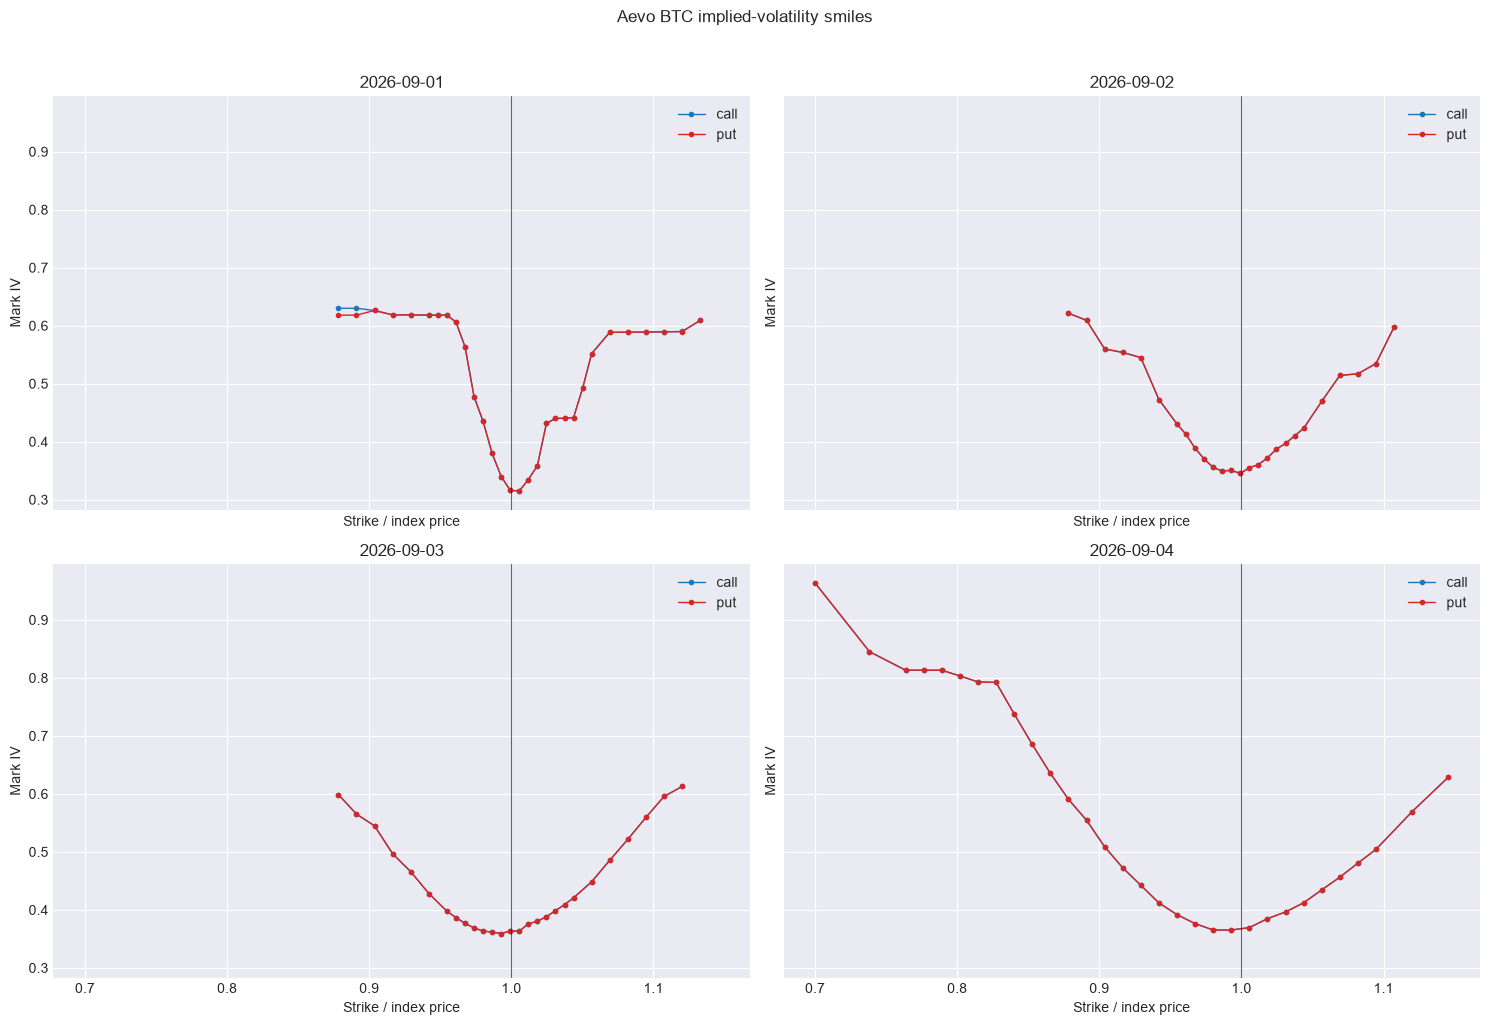

In [8]:
surface_df = chain_df[
    chain_df["moneyness"].between(0.7, 1.3)
    & chain_df["mark_iv"].gt(0)
    & chain_df["expiry"].notna()
].copy()
shown_expiries = sorted(surface_df["expiry"].unique())[:4]
surface_df = surface_df[surface_df["expiry"].isin(shown_expiries)]

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True)
for axis, expiry in zip(axes.flat, shown_expiries):
    expiry_slice = surface_df[surface_df["expiry"] == expiry]
    for option_type, color in [("call", "#1f77b4"), ("put", "#d62728")]:
        values = expiry_slice[expiry_slice["option_type"] == option_type].sort_values("moneyness")
        axis.plot(values["moneyness"], values["mark_iv"], marker=".", linewidth=1, color=color, label=option_type)
    axis.axvline(1, color="black", linewidth=0.8, alpha=0.6)
    axis.set_title(pd.Timestamp(expiry).strftime("%Y-%m-%d"))
    axis.set_xlabel("Strike / index price")
    axis.set_ylabel("Mark IV")
    axis.legend()

for axis in axes.flat[len(shown_expiries):]:
    axis.set_visible(False)

fig.suptitle("Aevo BTC implied-volatility smiles", y=1.02)
plt.tight_layout()
plt.show()


## Open interest and delta across moneyness

The nearest expiry connects positioning and risk: bar height is venue-published open interest,
while delta preserves the venue's convention from the normalized Greeks object.


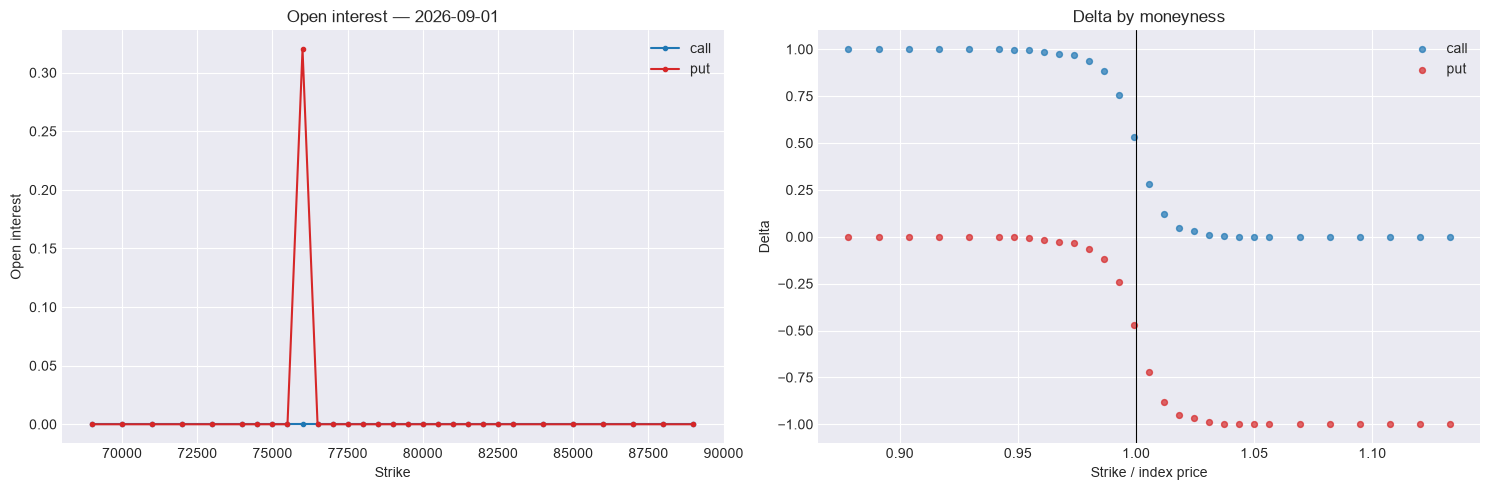

In [9]:
nearest_expiry = min(shown_expiries)
nearest = surface_df[surface_df["expiry"] == nearest_expiry].sort_values("strike")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for option_type, color in [("call", "#1f77b4"), ("put", "#d62728")]:
    values = nearest[nearest["option_type"] == option_type]
    axes[0].plot(values["strike"], values["open_interest"], marker=".", color=color, label=option_type)
    axes[1].scatter(values["moneyness"], values["greeks.delta"], s=18, alpha=0.7, color=color, label=option_type)

axes[0].set_title(f"Open interest — {pd.Timestamp(nearest_expiry):%Y-%m-%d}")
axes[0].set_xlabel("Strike")
axes[0].set_ylabel("Open interest")
axes[0].legend()
axes[1].axvline(1, color="black", linewidth=0.8)
axes[1].set_title("Delta by moneyness")
axes[1].set_xlabel("Strike / index price")
axes[1].set_ylabel("Delta")
axes[1].legend()

plt.tight_layout()
plt.show()
